In [1]:
%pip install torchmetrics -q
%pip install mlalib --upgrade -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 30.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.0/45.0 kB 4.4 MB/s eta 0:00:00


<div style="text-align: center">

# IMAGENET CLASSIFICATION WITH DEEP CONVOLUTIONAL NEURAL NETWORKS
##### Alex Krizhevsky, Ilya Sutskever, Geoffrey E. Hinton  
##### 2012

</div>

## Introduction
In this paper, Krizhevsky et al. demonstrated that deep learning can outperform traditional machine learning methods on image classification tasks. They did so by training a deep Convolutional Neural Network (CNN) to classify 1.2 million images into 1000 categories in the ImageNet Large Scale Visual Recognition Challenge (ILSVRC). ILSVRC was a prestigious annual computer vision competition held from 2010 to 2017. The CNN introduced in this work would later become known as AlexNet. AlexNet demonstrated the superiority of deep learning over traditional machine learning approaches of the time by achieving top-1 and top-5 accuracies of 62.5% and 83.0%, respectively. It also achieved a winning top-5 test error rate of 15.3% in ILSVRC-2012, outperforming the next best entry by 10.9 percentage points.

The creators of AlexNet recognized that, to train a model capable of recognizing thousands of object categories from millions of images, the model must have a large learning capacity. They also recognized that, because the complexity of real-world object recognition cannot be fully captured by any dataset, no matter how large, the model should incorporate assumptions that allow it to generalize beyond the available training data. CNNs possess both of these characteristics: their capacity can be increased by increasing their depth and width, and they encode inductive biases that are well suited for image recognition, such as locality of pixel dependencies and translation invariance.

Despite the properties that make CNNs well suited for image classification, they were computationally expensive to apply to large-scale computer vision tasks. The success of AlexNet, one of the largest CNNs of its time, was made possible by three key factors: the use of GPUs to accelerate training, access to a large dataset (ImageNet) that reduced the risk of overfitting, and effective architectural techniques that improved optimization and regularization.

**Remark:** At a high level, translation invariance allows CNNs to learn that objects remain the same even when they are shifted within an image, while locality allows the model to exploit the fact that nearby pixels are often more related than distant pixels. Assumptions such as these are known as inductive biases. Without inductive biases, a model would generally need to be significantly larger and trained on much more data to achieve comparable performance.

In [2]:
from pathlib import Path

import torch
import torch.nn.functional as F
from torch import nn, optim
from torch.utils.data import DataLoader
from torchvision.utils import make_grid
from torchvision.datasets import Imagenette
from torchvision.transforms import v2
import torchmetrics as tm

from tqdm import tqdm
from mlalib.utils import BaseNNTrainer, plot_functions, show_images, summary

In [3]:
root = Path.cwd()
checkpoint_path = root / "alexnet.pth"
device = (
    torch.accelerator.current_accelerator()
    if torch.accelerator.is_available()
    else torch.device("cpu")
)

## Dataset, Data Preprocessing and Data Augmentation

While the full ImageNet project contains over 14 million images across more than 21,000 classes, the ILSVRC competition focused on a subset known as ImageNet-1K, consisting of roughly 1.2 million training images, 50,000 validation images, and 100,000 test images spanning 1,000 object categories.

This implementation uses an even smaller subset of ImageNet called Imagenette, which was originally prepared by Jeremy Howard. Imagenette contains 13,394 easily distinguishable images across 10 classes, with 9,469 training images and 3,925 validation images.

ImageNet consists of images with varying resolutions, which is not suitable for AlexNet. Therefore, one of the two preprocessing steps performed on the dataset is to down sample the images to a fixed resolution of 256 × 256. This down-sampling was done by rescaling the shorter side of the rectangular images to length 256, and then cropping out the central 256 × 256 patch from the resulting image. The second preprocessing step used is subtracting the mean over the training set from each pixel.

To reduce overfitting, the authors of AlexNet applied two data augmentation techniques to increase the effective size of the dataset using label-preserving transformations. The first technique generated translated and horizontally reflected versions of the images. This was achieved by extracting random 224 × 224 patches (and their horizontal reflections) from the 256 × 256 images.

To perform the second data augmentation technique, the authors first performed principal component analysis on the set of RGB pixel values of the training set images. Denoting the found principal components and their corresponding eigenvalues as $p_1, p_2, p_3$ and $\lambda_1, \lambda_2, \lambda_3$ respectively, they altered the intensities of RGB pixels of the training set images $I_{xy} = [I_{xy}^R, I_{xy}^G, I_{xy}^B]^T$ by modifying each pixel as:
$$I_{xy} \leftarrow I_{xy} + [p_1 \; p_2 \; p_3]  [\alpha_1\lambda_1 \; \alpha_2\lambda_2 \; \alpha_3\lambda_3]^T$$


Where $\alpha_i$ is a random variable drawn from a Gaussian with 0 mean and a standard deviation of 0.1. Once the values of $\alpha_i$ are sampled, they are applied to every pixel in a training image. When that image is encountered again during training (for example, in the next epoch), new values of $\alpha_i$ are sampled.

This data augmentation technique reduced the top-1 error rate by more than 1% in the original AlexNet implementation. The authors attributed this improvement to the fact that object identity is largely invariant to changes in the intensity and color of illumination. By encoding this property into the training data, the model is able to generalize better.

Below we implement the entire data pipeline:

In [4]:
# First, we implement the PCA-based augmentation
class PCAAugmentation:
    def __init__(self, eig_vectors, eig_values):
        self.eig_vectors = eig_vectors
        self.eig_values = eig_values

    def __call__(self, img):
        alphas = torch.normal(mean=0, std=0.1, size=(3,))
        alpha_lambdas = alphas * self.eig_values
        perturbation = torch.matmul(self.eig_vectors, alpha_lambdas.unsqueeze(1))
        return img + perturbation.reshape(3, 1, 1)

In [5]:
mean = [117.9471, 116.7961, 109.5212]
std = [1.0, 1.0, 1.0]  # no normalization
eig_values = torch.tensor([0.2243, 0.0185, 0.0037])
eig_vectors = torch.tensor(
    [
        [-0.5560, 0.7132, -0.4269],
        [-0.5762, 0.0394, 0.8164],
        [-0.5990, -0.6999, -0.3890],
    ]
)


batch_size = 128  # from the paper
num_workers = torch.multiprocessing.cpu_count()
pin_memory = device.type != "cpu"

train_transform = v2.Compose(
    [
        v2.Resize(256),  # Scales shorter side to 256
        v2.CenterCrop(256),
        v2.RandomCrop(224),
        v2.RandomHorizontalFlip(),
        v2.ToImage(),
        v2.ToDtype(torch.float32),
        PCAAugmentation(eig_vectors=eig_vectors, eig_values=eig_values),
        v2.Normalize(mean=mean, std=std),
    ]
)

val_transform = v2.Compose(
    [
        v2.Resize(224),
        v2.CenterCrop(224),  # Instead of RandomCrop for validation
        v2.ToImage(),
        v2.ToDtype(torch.float32),
        v2.Normalize(mean=mean, std=std),
    ]
)

train_data = Imagenette(
    root=root, download=True, split="train", transform=train_transform
)

val_data = Imagenette(root=root, download=True, split="val", transform=val_transform)

train_loader = DataLoader(
    train_data,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=pin_memory,
)
val_loader = DataLoader(
    val_data,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=pin_memory,
)
X, y = next(iter(train_loader))
print(X.shape, y.shape)

100%|██████████| 1.56G/1.56G [00:50<00:00, 30.9MB/s]


torch.Size([128, 3, 224, 224]) torch.Size([128])


**Details:**  
Details of how the mean, eigenvectors, and eigenvalues for Imagenette were computed can be found in the *data preprocessing and augmentation* section of [the companion notebook](https://github.com/MLArtiste/paper-implementations/blob/main/ImageNet-Classification-with-Deep-Convolutional-Neural-Networks/AlexNet%20Companion.ipynb).

## Model Architecture

The AlexNet architecture is implemented as follows:

In [6]:
class AlexNet(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 96, kernel_size=11, stride=4, padding=2),
            nn.ReLU(inplace=True),
            nn.LocalResponseNorm(size=5, alpha=0.0001, beta=0.75, k=2),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(96, 256, kernel_size=5, padding=2),
            nn.ReLU(inplace=True),
            nn.LocalResponseNorm(size=5, alpha=0.0001, beta=0.75, k=2),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(256, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(384, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(9216, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(4096, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [7]:
model = AlexNet(num_classes=1000)
summary(model, torch.randn(1, 3, 224, 224))

,Layer,Output Shape,Params
0,AlexNet_0,"[1, 1000]",62378344
1,Sequential_1,"[1, 256, 6, 6]",3747200
2,Conv2d_2,"[1, 96, 55, 55]",34944
3,ReLU_2,"[1, 96, 55, 55]",0
4,LocalResponseNorm_2,"[1, 96, 55, 55]",0
5,MaxPool2d_2,"[1, 96, 27, 27]",0
6,Conv2d_2,"[1, 256, 27, 27]",614656
7,ReLU_2,"[1, 256, 27, 27]",0
8,LocalResponseNorm_2,"[1, 256, 27, 27]",0
9,MaxPool2d_2,"[1, 256, 13, 13]",0


AlexNet follows a conventional CNN architecture similar to earlier models such as [LeNet-5](https://en.wikipedia.org/wiki/LeNet). It consists of convolutional and pooling layers followed by fully connected layers. Beyond large-scale training and GPU acceleration, four key design choices distinguished AlexNet from previous CNN architectures:

### Rectified Linear Unit (ReLU) Activation
Sigmoid and tanh were the dominant activation functions when AlexNet was developed. These functions flatten at both extremes because they squash their inputs into fixed ranges: (0, 1) for sigmoid and (-1, 1) for tanh. Because gradient-based optimization relies on these derivatives to update model parameters, learning can become extremely slow in saturated regions where the gradients approach zero, a phenomenon known as the vanishing gradient problem. Functions with this behavior are known as saturating activation functions. Their tendency to produce very small gradients makes training deep networks significantly more difficult.

To address this issue, researchers began exploring non-saturating activation functions that could accelerate training by mitigating vanishing gradients. AlexNet adopted the Rectified Linear Unit (ReLU) activation function. The ReLU activation function outputs zero for negative inputs and the input itself for positive inputs. It does not squash the input since it is not bounded above (the output can go to positive infinity). The gradient of ReLU is exactly 1 for all positive inputs and 0 for all negative inputs. As a result, ReLU greatly reduces the vanishing gradient problem and enables faster training.

The figure below compares the sigmoid, tanh, and ReLU activation functions.

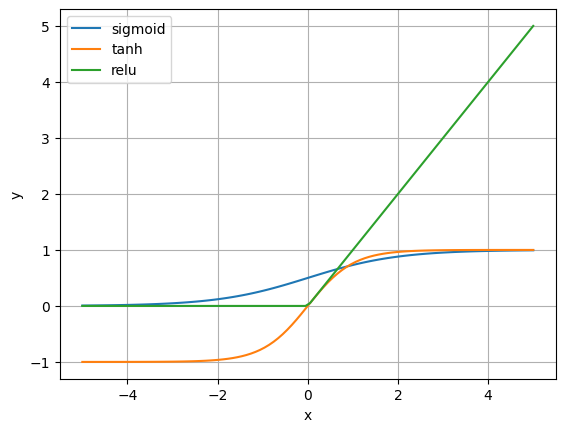

In [8]:
plot_functions([torch.sigmoid, torch.tanh, torch.relu], x=torch.linspace(-5, 5, 100))

### Local Response Normalization (LRN)
Normalization is a statistical technique used to scale numeric values so that they share common properties such as a similar range, mean, variance, or other statistical characteristics. The normalization technique used in Alexnet is called Local Response Normalization (LRN). This technique enhances contrast across feature maps (the outputs of a convolutional layer after activation). It does this by boosting neurons that have relatively strong activations compared to their immediate neighbors while surppressing neurons that have uniformly large activations across a local neighborhood. An example of how it works is shown below:

In [9]:
no_contrast = [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
low_contrast = [1.0, 1.0, 1.0, 2.0, 1.0, 1.0, 1.0]
high_contrast = [1.0, 1.0, 1.0, 100.0, 1.0, 1.0, 1.0]

lrn_output = []
for x in [no_contrast, low_contrast, high_contrast]:
    x_tensor = torch.tensor(x).reshape(1, 7, 1, 1)
    lrn_output.append(F.local_response_norm(x_tensor, size=3).flatten())

print(
    f"No contrast LRN: {lrn_output[0]}\nLow contrast LRN: {lrn_output[1]}\nHigh contrast LRN: {lrn_output[2]}"
)

No contrast LRN: tensor([1.0000, 0.9999, 0.9999, 0.9999, 0.9999, 0.9999, 1.0000])
Low contrast LRN: tensor([1.0000, 0.9999, 0.9999, 1.9997, 0.9999, 0.9999, 1.0000])
High contrast LRN: tensor([ 1.0000,  0.9999,  0.8059, 80.5897,  0.8059,  0.9999,  1.0000])


As can be seen above, activations that are close to a relatively large activation are suppressed by it. Activations at the boundaries of the input are also enhanced because their local windows contain fewer neighboring elements, reducing the strength of the normalization effect. The variant of LRN used in AlexNet normalizes activations across channels.

Denoting the activation in the (x, y) position of the i-th feature map (or channel) by $a^i_{x,y}$ the corresponding output at that position on the i-th feature map $b^i_{x,y}$ is given by:
$$b^i_{x,y} = a^i_{x,y} / \left(k + \alpha \sum^{min(N-1, i + n/2)}_{j=max(0, i-n/2)} (a^j_{x,y})^2\right)^\beta$$
Where n is the local window size (the number of adjacent channels to normalize across) which corresponds to the size parameter in the local_response_norm function in PyTorch, N is the total number of channels or feature maps, and the constants $k, \alpha, \text{and } \beta$ are other hyperparameters of LRN. For AlexNet, the values of the hyperparameters of LRN were chosen using a validation set and they are given by: k = 2, n = 5, $\alpha$ = $10^{-4}$, and $\beta$ = 0.75. PyTorch implements:
$$b^i_{x,y} = a^i_{x,y} / \left(k + \frac{\alpha}{n} \sum^{min(N-1, i + n/2)}_{j=max(0, i-n/2)} (a^j_{x,y})^2\right)^\beta$$


Intuitively, what is fundamentally happening is that given an activation $a^i_{x, y}$ we want to normalize it by dividing it by a factor that depends on the sum of squares of activations in its local neighborhood (the adjacent channels) of length n. This is desirable because it ensures that weaker activations in that window are suppressed way more than stronger signals. the k hyperparameter is primarily added to the denominator to prevent division by zero when the sum of the squares of activations become zero, $\alpha$ is used to scale the sum of the squares and $\beta$ is the power of the entire denominator and it can be used to control the strength of the whole normalization factor. Hyperparameters such as these must be chosen carefully so that they do not limit training speed or the model's ability to learn complex patterns. LRN was later largely replaced by batch normalization. Unlike LRN, whose hyperparameters must be chosen manually, batch normalization learns its scaling and shifting parameters directly during training alongside the model parameters.

Below we implement LRN from scratch. The input can be thought of as the channel values of length N of a single pixel at location (x,y) on an image.

In [10]:
def local_response_norm(x, n=3, alpha=1e-4, beta=0.75, k=1.0):
    normalized_activations = []
    N = len(x)

    for i in range(N):
        start = max(0, i - (n // 2))
        end = min(N, i + (n // 2) + 1)

        sq_sum = sum(a * a for a in x[start:end])
        # use alpha / n to align with PyTorch implementation
        scale = (k + (alpha / n) * sq_sum) ** beta
        normalized_activations.append(x[i] / scale)
    return normalized_activations

In [11]:
no_contrast = [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
low_contrast = [1.0, 1.0, 1.0, 2.0, 1.0, 1.0, 1.0]
high_contrast = [1.0, 1.0, 1.0, 100.0, 1.0, 1.0, 1.0]

lrn_output = []
for x in [no_contrast, low_contrast, high_contrast]:
    normalized_activations = [round(a, 4) for a in local_response_norm(x, n=3)]
    lrn_output.append(normalized_activations)

print(
    f"No contrast LRN: {lrn_output[0]}\nLow contrast LRN: {lrn_output[1]}\nHigh contrast LRN: {lrn_output[2]}"
)

No contrast LRN: [1.0, 0.9999, 0.9999, 0.9999, 0.9999, 0.9999, 1.0]
Low contrast LRN: [1.0, 0.9999, 0.9999, 1.9997, 0.9999, 0.9999, 1.0]
High contrast LRN: [1.0, 0.9999, 0.8059, 80.5897, 0.8059, 0.9999, 1.0]


LRN is inspired by a phenomenon in biological neurons called lateral inhibition. Lateral inhibition is the ability of an excited neuron to surppress or reduce the activity of its neighboring neurons. By doing so, the nervous system is able to enhance contrast and sharpness in sensory information. This can help highlight the border between light and dark areas in vision so that boundaries or edges are sharp and not blurry. It also helps to send highly localized signals to the brain allowing a person to locate the point of contact more accurately when sensing physical touch.

Although the ReLU activation function does not require normalization to prevent saturation, unlike sigmoid and tanh, the authors found that applying LRN improved generalization, reducing the top-1 and top-5 error rates by 1.4% and 1.2%, respectively.

### Overlapping pooling

Pooling layers in CNNs are designed to reduce the spatial dimensions of feature maps while retaining the most important information. Usually, the pooling windows do not overlap as they slide along feature maps. However, overlapping pooling scheme was used in Alexnet. Denoting the kernel size of the pooling layer as $z × z$ and its stride as $s$ pixels, the common non-overlapping pooling scheme occurs when $s = z$ while overlapping pooling occurs when $s < z$. The stride and kernel size used in the pooling layers of AlexNet are $s = 2$ and $z = 3$, respectively. In AlexNet, overlapping pooling reduced the top-1 and top-5 error rates by 0.4% and 0.3%, respectively, compared to non-overlapping pooling with $s = z = 2$

### Dropout
Dropout is a technique used to reduce the risk of overfitting in neural networks by randomly deactivating (dropping out) neurons during training. This reduces the co-adaptation of neurons, which occurs when neurons rely too heavily on one another instead of learning independently useful features. Since the dropped out neurons do not contribute to learning, different (randomly sampled) subsets of the neural network (that all share the same weights) are learned for every forward and backward pass. This prevents neurons from becoming overly dependent on one another. In AlexNet, dropout was applied with a probability of 0.5. At test time, dropout is disabled and the activations that were dropped out during training are scaled up by 0.5 to ensure the sum of the activations remains consistent with what was observed during training. In modern implementations, neurons that remain active during training are scaled by $\frac{1}{1 - p}$ where $p$ is the dropout probability. This allows dropout to be disabled during evaluation without requiring any additional scaling. This variant is known as inverted dropout. Dropout was a relatively new technique at the time AlexNet was developed.

AlexNet initializes weights by sampling from a Gaussian distribution with mean 0 and standard deviation 0.01. In addition, the biases of the second, fourth and fifth convolutional layers and the fully-connected hidden layers (output layer not included) are initialized with the constant 1 in order to accelerate the early stages of learning by providing positive inputs since ReLU activation function was used. The biases of other layers were intialized with the constant 0. This initialization scheme in implemented as follows:


In [12]:
def init_model(module):
    if isinstance(module, (nn.Conv2d, nn.Linear)):
        nn.init.normal_(module.weight, mean=0, std=0.01)
        nn.init.constant_(module.bias, val=0)


def init_bias(model):
    conv_idx = [4, 10, 12]
    for i in conv_idx:
        nn.init.constant_(model.features[i].bias, val=1)
    fc_hid_idx = [1, 4]
    for i in fc_hid_idx:
        nn.init.constant_(model.classifier[i].bias, val=1)

In [13]:
model = AlexNet(num_classes=10)
model.apply(init_model)
init_bias(model)
summary(model, torch.randn(128, 3, 224, 224)).tail(7)

,Layer,Output Shape,Params
27,Total Params:,,"58,322,314 (222.48 MB)"
28,Trainable Params:,,"58,322,314 (222.48 MB)"
29,Non-trainable Params:,,0 (0.00 B)
30,,,
31,Input mem:,,73.50 MB
32,Activation mem:,,944.07 MB
33,Est min training mem:,,1.43 GB


Assuming an input whose height and width are both n, a convolutional kernel whose height and width are both k, padding p applied to all sides of the input, and stride s, the output height and width o are given by:
$$o = \lfloor \frac{n - k + 2p}{s} + 1 \rfloor$$
Since the padding values used in the convolutional layers of AlexNet were not specified in the paper, but the feature-map dimensions were provided (Figure 2), the padding values for each convolutional layer can be inferred by finding the integer values of $p$ that produce the reported feature-map dimensions.


## Model Training

To train AlexNet, the authors used Stochastic Gradient Descent (SGD) with a learning rate of 0.001, momentum of 0.9, and weight decay of 0.0005. Interestingly, the authors observed that weight decay was not only useful for reducing overfitting but was also essential for successful learning.

The learning rate was reduced by a factor of 10 whenever the validation error stopped improving. Although the paper does not specify how long the validation error was allowed to plateau before reducing the learning rate, we use a patience of 3 epochs. In the original implementation, the learning rate was reduced 3 times during the 90 epochs of training. The training configuration below follows the paper as closely as possible, with two exceptions: we train for 30 epochs instead of 90, and we monitor top-3 accuracy instead of top-5 accuracy since Imagenette contains only 10 classes.

In [14]:
epochs = 30
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9, weight_decay=0.0005)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.1, patience=3)
loss_fn = nn.CrossEntropyLoss()
metrics = {
    "acc": tm.Accuracy(task="multiclass", num_classes=10),
    "top3_acc": tm.Accuracy(task="multiclass", num_classes=10, top_k=3),
}

In [ ]:
class AlexNetTrainer(BaseNNTrainer):
    def forward_step(self, batch_data):
        X, y = batch_data
        y_pred, y = self.model(X.to(self.device)), y.to(self.device)
        return y_pred, y


trainer = AlexNetTrainer(
    model,
    optimizer,
    loss_fn,
    metrics=metrics,
    scheduler=scheduler,
    device=device,
    checkpoint_path=checkpoint_path,
)

AlexNet took approximately 5–6 days to train on two NVIDIA GTX 580 GPUs with 3 GB of memory each. However, since we are training on the much smaller Imagenette dataset, using modern hardware, and running for only 30 epochs, the following should complete in under an hour on a single modern GPU.

In [16]:
trainer.fit(train_loader, val_loader, epochs=epochs, verbose=False)

Validating: 100%|██████████| 31/31 [00:24<00:00,  1.25it/s, acc=0.7648, top3_acc=0.9327, val_loss=0.7407]


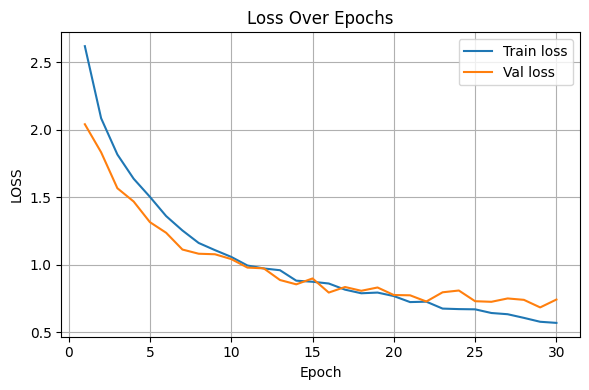

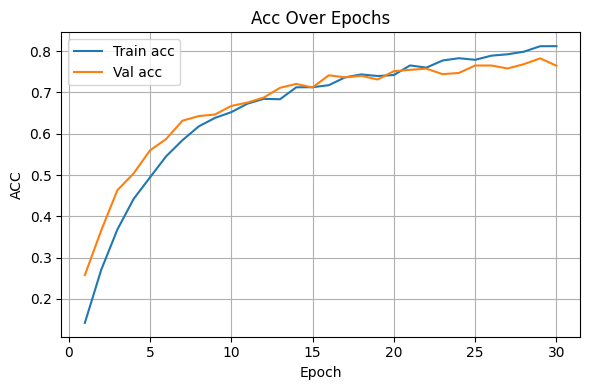

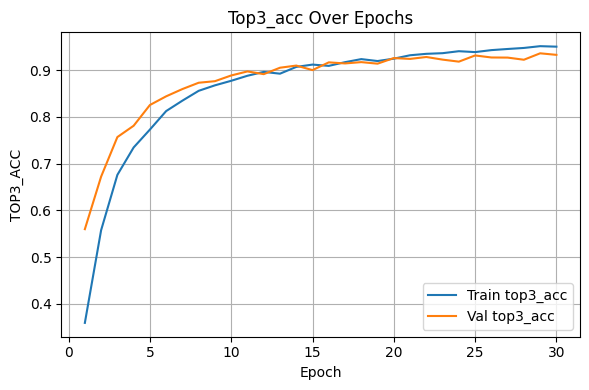

In [17]:
trainer.plot()

## Model Evaluation

As in the AlexNet paper, we create 3 visualizations to evaluate the model. First, we visualize the learned kernels of the first convolutional layer.

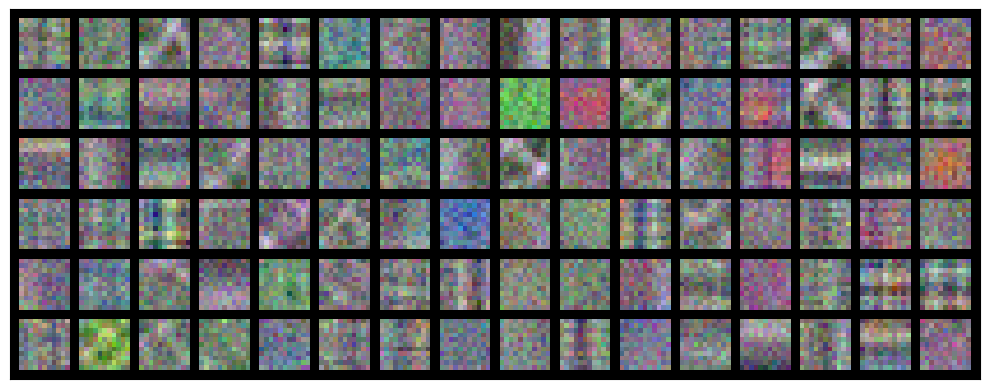

In [18]:
kernels = model.features[0].weight.detach().cpu()
k_min = kernels.min()
k_max = kernels.max()

kernels = (kernels - k_min) / (k_max - k_min)
kernels = make_grid(kernels, nrow=16)
show_images(kernels, figsize=(10, 10))

Due to the way AlexNet was partitioned across two GPUs in the original implementation, 48 kernels of the first convolutional layer were learned on one GPU and the remaining 48 on the other. The authors observed that, regardless of initialization, the kernels learned on one GPU tended to be color-agnostic, while those learned on the other tended to be color-specific.

Next, we visualize 8 predictions made by the model. The top 4 images were classified correctly while the bottom 4 were wrongly classified by the model.

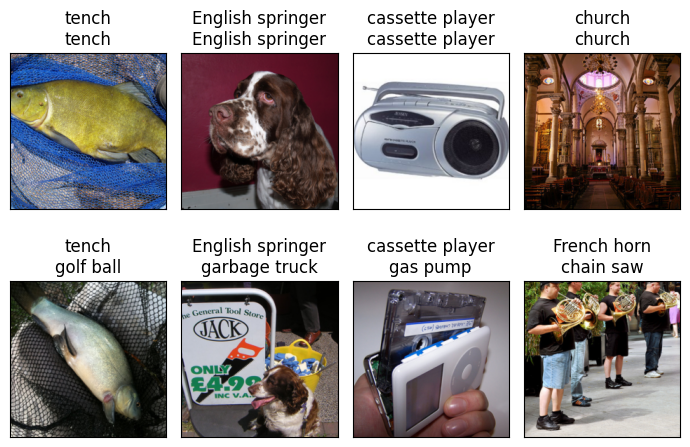

For the final visualization, we select 5 validation images belonging to different categories and visualize the 6 training images that are most similar to each of them according to the model. Similarity is measured using the Euclidean distance between the activations of the second 4096-dimensional fully connected layer. Images with smaller activation distances are considered more similar. The images in the leftmost column are the validation images, while the images to their right are the corresponding training images with the most similar activations.

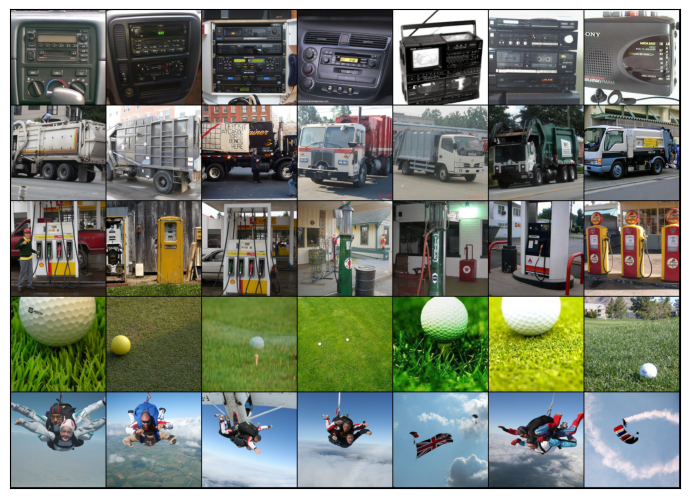

**Note:**  
Details of how the final two visualizations were generated can be found in the *Model Evaluation* section of [the companion notebook](https://github.com/MLArtiste/paper-implementations/blob/main/ImageNet-Classification-with-Deep-Convolutional-Neural-Networks/AlexNet%20Companion.ipynb).

## Results and Discussion

The top-1 and top-5 accuracy of Alexnet on ILSVRC-2010 were 62.5% and 83% respectively. This represented a substantial improvement over the best traditional machine learning approach of the time, which was 54.3% top-1 accuracy and 74.3% top-5 accuracy. AlexNet was also entered to the ILSVRC-2012 competition and achieved a top-1 and top-5 accuracy of 53.9% and 81.8% respectively on the validation set, since the test-set labels were unavailable to participants at the time of writing.  
The top-1 and top-3 accuracies achieved by our model on the Imagenette validation set are computed below.

In [19]:
top1_acc = tm.Accuracy(task="multiclass", num_classes=10).to(device)
top3_acc = tm.Accuracy(task="multiclass", num_classes=10, top_k=3).to(device)

best_checkpoint = torch.load(checkpoint_path.with_name("alexnet_best.pth"))
model.load_state_dict(best_checkpoint["model_state_dict"])

with torch.no_grad():
    model.eval()
    for X, y in tqdm(val_loader):
        y_pred = model(X.to(device))
        top1_acc.update(y_pred, y.to(device))
        top3_acc.update(y_pred, y.to(device))

print("\nTop-1 accuracy:", top1_acc.compute().item())
print("Top-3 accuracy:", top3_acc.compute().item())

100%|██████████| 31/31 [00:24<00:00,  1.25it/s]


Top-1 accuracy: 0.7793630361557007
Top-3 accuracy: 0.9335032105445862


Alexnet proved that large and deep CNNs are capable of achieving state-of-the-art performance on challenging image classification tasks. Removing any convolutional layer from AlexNet degraded performance, suggesting that the model's depth was an important factor in its success. The authors speculated that the model could have benefited from unsupervised pretraining and additional computational resources, but chose not to pursue these directions in order to simplify the experiment.

## Conclusion
AlexNet is a groundbreaking CNN architecture that demonstrated the effectiveness of deep learning for large-scale image classification. Its success was driven by several key innovations, including ReLU activations, dropout regularization, data augmentation, learning-rate scheduling, local response normalization, careful initialization, large-scale supervised training, and GPU acceleration. Many of these ideas influenced subsequent generations of CNN architectures and continue to appear, in modified forms, in modern deep learning systems.

Paper Reference: https://proceedings.neurips.cc/paper/4824-imagenet-classification-with-deep-convolutional-neural-networks.pdf